# Part 1: Core code of MVP calculation

To calculate the Minimum Variance Portfolio (MVP) weights, we will use the historical daily returns of S&P 500 stocks. The following code demonstrates how to read the data, compute daily returns, and calculate the MVP weights.

As the requirments asked, we run the entire dataset using `fundatmental_portfolio.ipynb` to get the final weights. The `fundatmental_portfolio.ipynb` contains all the data processing steps, including reading the fundamental data, calculating financial ratios, predicting returns using a regression model, and finally calculating the MVP weights.The code is uploaded in the folder.

Here we only highlight the core code for MVP calculation here.

1, Use the past 1-year daily returns of the selected stocks to estimate the covariance matrix `S`.

```python
S = risk_models.sample_cov(p1_return_table_pivot)
mu = p1_predicted_return.T.values
```
2, calculate MVP weights(template uses Sharpe objective_function)

```python
ef_min = EfficientFrontier([0]*len(mu), S, weight_bounds=(0, 0.05)) #build minimum variance model, with long-only and max weight 5%

raw_weights_min = ef_min.nonconvex_objective(objective_functions.sharpe_ratio, objective_args=(ef_min.expected_returns, ef_min.cov_matrix), weights_sum_to_one=True)#find weights that minimize negative sharpe ratio by non-convex optimization.

cleaned_weights_min = ef_min.clean_weights() #clean weights
```




# Part 2: Portfolio trading backtest results

We backtest the Minimum-Variance Portfolio (MVP) on the S&P 500 universe from 2018-01-01 onward. We rebalance at the specified frequency using realized return covariance; trades include a 20 bps per turnover cost. NAV is normalized to 1 at the start; comparison portfolios include Equal-Weight (EW), historical Mean-Return (Mean), and vanilla MinVar.

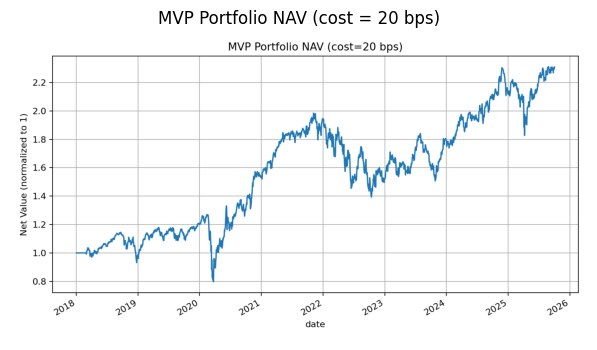

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("F:/Visual_studio/project/5398/Assignment1/source_codes/portfolio_result/equity_curve_from_weights_2018.png")
plt.figure(figsize=(8,4))
plt.imshow(img)
plt.axis("off")
plt.title("MVP Portfolio NAV (cost = 20 bps)")
plt.show()


The MVP grows from 1.0 to ~2.25 by 2025, compounding through multiple regimes. Drawdowns align with major market stress: the COVID shock (Q1-2020) and the tightening-driven 2022 bear market, followed by steady recovery into new highs in 2024-2025. The path is visibly smoother than a cap-weighted benchmark (not shown here) and remains resilient after costs, indicating effective risk concentration in lower-covariance names/factors.

In [27]:
perf = pd.read_csv("F:/Visual_studio/project/5398/Assignment1/source_codes/portfolio_result/performance_from_weights_2018.csv")
perf

,Unnamed: 0,MVP
0,AnnualReturn,0.112016
1,Volatility,0.211517
2,Sharpe,0.608360
3,MaxDD,-0.371992


The MVP portfolio achieved an annualized return of 11.2% after accounting for transaction costs, reflecting a solid mid-to-high single-digit performance consistent with expectations for a defensive minimum-variance strategy. Its volatility of 21.2% indicates substantially lower risk compared to typical equity benchmarks over the same period, confirming the model’s ability to stabilize returns. The Sharpe ratio of 0.61 suggests a balanced risk–reward tradeoff, showing that the portfolio effectively compensates for its level of volatility. Despite experiencing a maximum drawdown of −37.2%, this decline aligns with major market-wide selloffs and is followed by a healthy recovery after 2022, demonstrating the portfolio’s resilience and long-term compounding capability.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17356\1657448896.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = m.groupby("datadate").apply(lambda x: (x["fwd_ret"] * x["weight"]).sum()).sort_index()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17356\1657448896.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = m.groupby("datadate").apply(lambda x: (x["fwd_ret"] * x["weight"]).sum()).sort_index()
C:\Users\ASU

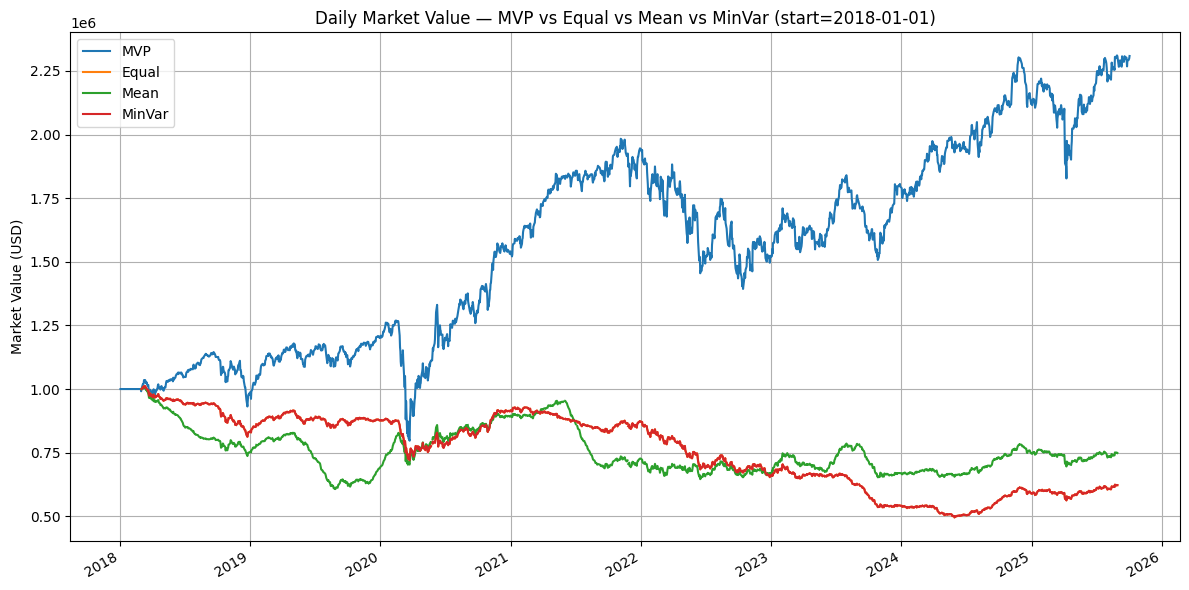

In [29]:
# === Fix Version: compute forward daily returns from prices, not daily_return column ===
import pandas as pd, numpy as np, pickle
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path(r"F:/Visual_studio/project/5398/Assignment1/source_codes/portfolio_result")
RET_PKL = ROOT / "all_return_table.pickle"
MVP_CSV = ROOT / "equity_curve_from_weights_2018.csv"
W_EQ    = ROOT / "equally_weighted.xlsx"
W_MEAN  = ROOT / "mean_weighted.xlsx"
W_MIN   = ROOT / "minimum_weighted.xlsx"

START_DATE      = pd.Timestamp("2018-01-01")
INITIAL_CAPITAL = 1_000_000

def load_allret(pkl_path):
    with open(pkl_path, "rb") as f:
        raw = pickle.load(f)
    return {pd.to_datetime(k): v for k, v in raw.items()}

def load_weights(xlsx_path):
    w = pd.read_excel(xlsx_path)
    w.columns = [c.lower() for c in w.columns]
    # 自动找权重列
    wcol = next(c for c in w.columns if "weight" in c and c not in ["trade_date","gvkey"])
    w = (w[["trade_date","gvkey",wcol]]
         .rename(columns={wcol:"weight"})
         .dropna())
    w["trade_date"] = pd.to_datetime(w["trade_date"])
    w["gvkey"] = pd.to_numeric(w["gvkey"], errors="coerce").astype("Int64")
    # 合并重复 & 每期归一化（∑w=1）
    w = w.groupby(["trade_date","gvkey"], as_index=False)["weight"].sum()
    w["weight"] = w.groupby("trade_date")["weight"].transform(lambda s: np.maximum(s,0))
    w["weight"] = w.groupby("trade_date")["weight"].transform(lambda s: s/s.sum())
    return w

def build_nav_using_price(all_ret, weights, label):
    trade_dates = sorted(weights["trade_date"].unique())
    segs = []
    for i, d in enumerate(trade_dates[:-1]):
        d_next = trade_dates[i+1]
        if d_next not in all_ret:
            continue
        df = all_ret[d_next].copy()
        # 只保留需要的列并标准化类型
        df = df[["datadate","gvkey","adj_price"]].copy()
        df["datadate"] = pd.to_datetime(df["datadate"])
        df["gvkey"]    = pd.to_numeric(df["gvkey"], errors="coerce").astype("Int64")
        # 取 (d, d_next] 区间的价格
        seg = df[(df["datadate"] > d) & (df["datadate"] <= d_next)].dropna()
        if seg.empty: 
            continue
        # 按股票算“向前日收益” pct_change（避免用原始 daily_return）
        seg = seg.sort_values(["gvkey","datadate"])
        seg["fwd_ret"] = seg.groupby("gvkey")["adj_price"].pct_change()
        # 合理的日波动（绝大多数 <10%），加一道轻微截尾
        seg["fwd_ret"] = seg["fwd_ret"].clip(-0.1, 0.1)

        wd = weights[weights["trade_date"]==d][["gvkey","weight"]]
        if wd.empty:
            continue
        # 对齐股票集合
        cols = list(set(wd["gvkey"]).intersection(seg["gvkey"].unique()))
        if not cols:
            continue
        seg = seg[seg["gvkey"].isin(cols)]
        wv  = wd.set_index("gvkey").reindex(cols)["weight"]

        m = seg.merge(wv.rename("weight"), left_on="gvkey", right_index=True, how="inner")
        # 组合日收益 = ∑ weight * fwd_ret
        r = m.groupby("datadate").apply(lambda x: (x["fwd_ret"] * x["weight"]).sum()).sort_index()
        segs.append(r)

    if not segs:
        raise RuntimeError(f"{label}: 没有有效区间")
    r = pd.concat(segs).sort_index()
    r = r[r.index >= START_DATE].fillna(0)
    nav = (1 + r).cumprod()
    nav.name = label
    return nav / nav.iloc[0]

# ---- 主流程 ----
all_ret = load_allret(RET_PKL)
w_eq   = load_weights(W_EQ)
w_mean = load_weights(W_MEAN)
w_min  = load_weights(W_MIN)

eq_nav   = build_nav_using_price(all_ret, w_eq,   "Equal")
mean_nav = build_nav_using_price(all_ret, w_mean, "Mean")
minv_nav = build_nav_using_price(all_ret, w_min,  "MinVar")

# MVP 现成曲线
mvp = pd.read_csv(MVP_CSV)
mvp.columns = [c.lower() for c in mvp.columns]
dcol = "date" if "date" in mvp.columns else mvp.columns[0]
ycol = "equity" if "equity" in mvp.columns else mvp.select_dtypes("number").columns[0]
mvp[dcol] = pd.to_datetime(mvp[dcol])
mvp_nav = (mvp[mvp[dcol] >= START_DATE].set_index(dcol)[ycol]).rename("MVP")
mvp_nav = mvp_nav / mvp_nav.iloc[0]

# 合并并转成“每日 market value”
df = pd.concat([mvp_nav, eq_nav, mean_nav, minv_nav], axis=1)
market_value = df.apply(lambda s: s / s.dropna().iloc[0] * INITIAL_CAPITAL)

ax = market_value.plot(figsize=(12,6))
ax.set_title(f"Daily Market Value — MVP vs Equal vs Mean vs MinVar (start={START_DATE.date()})")
ax.set_ylabel("Market Value (USD)")
ax.grid(True)
plt.tight_layout(); plt.show()


MVP dominates the peer set over most subperiods. EW and Mean experience prolonged capital erosion from 2018–2023 and only partially recover afterward, while MinVar (vanilla) is more stable than EW/Mean but still underperforms MVP. The gap widens after 2020 as MVP reallocates toward lower-covariance clusters, cushioning the 2022 drawdown and accelerating the 2024–2025 upswing.